# Tournoi commun A / B / ensemble fixe 50/50

Évaluation des modèles figés sur **2023, 2024 et 2025**. Aucun nouveau modèle, aucun réglage de paramètres, aucun forecast 2026. Toute sortie est agrégée ; les CSV confidentiels restent intacts.

**Model B — full hierarchical** = `P1_G1`, représentation principale demandée et **non champion sélectionné**. Les quatre combinaisons existantes sont conservées. Audit complet : [comparaison A/B](../docs/model_ab_comparison.md).

La sécurité est celle du contrat daté existant, conditionnelle à la fidélité historique CRM ; aucun journal de versions ne permet de la certifier sans réserve.

## Contrat et audit B

`p_i` estime la probabilité de transition ; `g_i` est une estimation conditionnelle fondée sur des médianes ; `c_i=p_i*g_i` ; **P1 = 100 × médiane des contributions de la cohorte**. L'indice conventionnel n'est ni une espérance conditionnelle démontrée ni le rent roll.

Clé `(sPropCode, sUnitCode)`, cohorte à échéance connue au 31 décembre Y−1, annualisation effective entre débuts, zéro uniquement pour absence de transition admissible dans l'extrait. Plusieurs transitions d'une unité sont moyennées dans son label réalisé.

B full utilise occurrence **global → province → province/mois d'échéance**, shrinkage 20, support minimum 1 ; croissance **global → province**, shrinkage 1, support minimum 10. Pas de segmentation bâtiment dans cette combinaison. Ontario insuffisamment appris : repli global. Aucun `sRenewal` futur, effectif courant, concessions, asking ou externe comme feature.

Les features du train sont reconstruites à leur propre origine ; les labels début/signature/fin doivent être mûrs à la coupure. Les defaults `ModelB()` diffèrent de la shortlist : on réutilise explicitement les configurations figées du tournoi existant.

In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / 'src').is_dir():
    ROOT = ROOT.parent
assert (ROOT / 'src').is_dir(), 'Exécuter depuis le dépôt ou notebooks/.'
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
leases = pd.read_csv(ROOT / 'data/raw/equinoxe_lease_history.csv',
                     dtype={'sPropCode': 'string', 'sUnitCode': 'string'})
# Les baux et les vecteurs unitaires restent en mémoire, sans affichage ni export.


## Références, cohorte et comparabilité

Arrêt automatique si A ne reproduit pas les références, si les clés/labels A et B diffèrent, ou si l'adaptateur ne reproduit pas les quatre forecasts B existants. Les contrôles incluent la cohorte 2026 **sans forecast**.

A entraîne la croissance sur des unités/années positives qualifiées ; B sur toutes les transitions mûres. Cette différence de train est conservée et documentée ; le scoring P1 porte sur la même population.

In [2]:
from src.evaluation.model_ab_tournament import run_tournament, B_LABEL
results = run_tournament(leases)
display(results['foundation'])
display(results['comparability'])

,year,candidates,observed_units,prediction_origin
0,2023,405,401.0,2022-12-31
1,2024,645,634.0,2023-12-31
2,2025,856,773.0,2024-12-31
3,2026,931,NaN,2025-12-31


,year,prediction_origin,candidate_units,observed_units,identical_keys,identical_labels,qualified_occurrence,pending_labels,growth_A_unit_years,growth_B_transitions,temporal_status
0,2023,2022-12-31,405,401,True,True,897,351,882,952,SAFE_WITH_CONDITIONS
1,2024,2023-12-31,645,634,True,True,1246,407,1227,1318,SAFE_WITH_CONDITIONS
2,2025,2024-12-31,856,773,True,True,1657,641,1627,1759,SAFE_WITH_CONDITIONS


## Tableau principal et métriques communes

Forecasts en %, erreurs en points de pourcentage. Le 50/50 est la moyenne **des forecasts scalaires**, avec poids fixes ; la médiane d'un mélange unitaire serait une autre opération.

In [3]:
display(results['common'].round(6))
display(results['metrics'].round(6))

,year,realized_P1,A_prediction,B_prediction,A_error,B_error,ensemble_prediction,ensemble_error
0,2023,2.036102,2.870060,2.871314,0.833957,0.835212,2.870687,0.834585
1,2024,1.607852,3.269179,3.236099,1.661326,1.628247,3.252639,1.644787
2,2025,3.300878,2.969328,2.924144,-0.331551,-0.376735,2.946736,-0.354143


,model,MAE_pp,RMSE_pp,bias_pp,worst_absolute_error_pp
0,A,0.942278,1.090171,0.721244,1.661326
1,Model B — full hierarchical,0.946731,1.078687,0.695575,1.628247
2,A/B 50-50,0.944505,1.084323,0.708410,1.644787


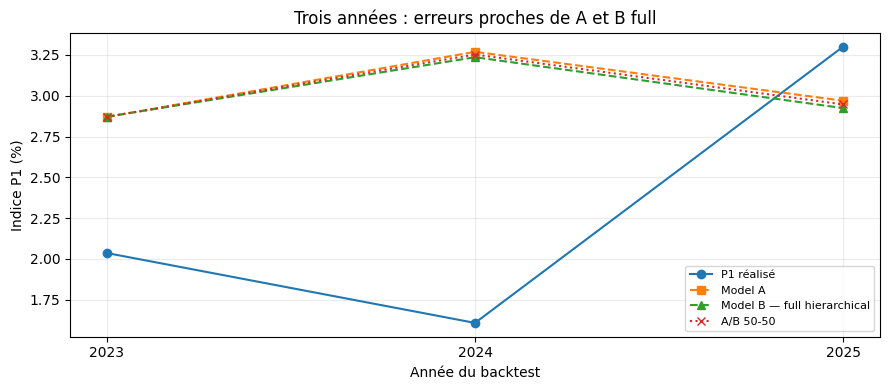

In [4]:
import matplotlib.pyplot as plt
common = results['common']
fig, ax = plt.subplots(figsize=(9, 4))
for column, label, style in [
    ('realized_P1', 'P1 réalisé', 'o-'),
    ('A_prediction', 'Model A', 's--'),
    ('B_prediction', B_LABEL, '^--'),
    ('ensemble_prediction', 'A/B 50-50', 'x:'),
]:
    ax.plot(common.year, common[column], style, label=label)
ax.set(xticks=[2023, 2024, 2025], xlabel='Année du backtest',
       ylabel='Indice P1 (%)', title='Trois années : erreurs proches de A et B full')
ax.grid(alpha=.25)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
plt.close(fig)

## Les quatre variantes B, sans nouvelle sélection

P0 = occurrence globale ; P1 = occurrence hiérarchique province/mois. G0 = médiane Y−1 mûre ; G1 = croissance provinciale hiérarchique. La présence d'un meilleur score ne sélectionne aucun champion final.

In [5]:
display(results['all_B_results'].round(6))
display(results['all_B_metrics'].round(6))

,year,model_name,candidate_count,predicted_P1_percent,observed_P1_percent,error_pp,absolute_error_pp,predicted_occurrence_rate,observed_occurrence_rate,predicted_conditional_growth_percent,observed_conditional_growth_percent
0,2023,P0_G0,405,2.226208,2.036102,0.190105,0.190105,0.983278,0.990123,2.264068,2.085372
1,2023,P0_G1,405,2.833380,2.036102,0.797278,0.797278,0.983278,0.990123,2.881567,2.085372
2,2023,P1_G0,405,2.256013,2.036102,0.219911,0.219911,0.985538,0.990123,2.264068,2.085372
3,2023,P1_G1,405,2.871314,2.036102,0.835212,0.835212,0.985538,0.990123,2.881567,2.085372
4,2024,P0_G0,645,1.115963,1.607852,-0.491889,0.491889,0.984751,0.982946,1.133244,1.699619
5,2024,P0_G1,645,3.195010,1.607852,1.587158,1.587158,0.984751,0.982946,3.244485,1.699619
6,2024,P1_G0,645,1.130315,1.607852,-0.477538,0.477538,0.984776,0.982946,1.133244,1.699619
7,2024,P1_G1,645,3.236099,1.607852,1.628247,1.628247,0.984776,0.982946,3.244485,1.699619
8,2025,P0_G0,856,2.200054,3.300878,-1.100824,1.100824,0.981895,0.903037,2.240621,3.716980
9,2025,P0_G1,856,2.878542,3.300878,-0.422336,0.422336,0.981895,0.903037,2.931619,3.716980


,model_name,p1_mae_pp,p1_rmse_pp,p1_bias_pp,worst_absolute_yearly_error_pp,p1_mae_rank,p1_rmse_rank,p1_bias_rank,worst_absolute_error_rank
0,P0_G0,0.594273,0.704724,-0.467536,1.100824,2,2,2,2
1,P0_G1,0.935591,1.054054,0.654033,1.587158,3,3,3,3
2,P1_G0,0.587807,0.686221,-0.441200,1.065971,1,1,1,1
3,P1_G1,0.946731,1.078687,0.695575,1.628247,4,4,4,4


## Complémentarité des composantes

Les taux et Brier utilisent toutes les candidates ; les erreurs de croissance utilisent les mêmes unités positives. Erreur de médiane, MAE individuelle et erreur P1 sont des statistiques différentes.

In [6]:
display(results['components'].round(6))
complementarity = results['common'][['year', 'A_error', 'B_error']].copy()
complementarity['same_error_sign'] = (
    complementarity.A_error * complementarity.B_error > 0)
display(complementarity)

,year,model,historical_occurrence_pct,predicted_occurrence_pct,realized_occurrence_pct,occurrence_error_pp,Brier,predicted_growth_pct,realized_growth_pct,growth_median_error_pp,growth_MAE_pp,growth_bias_pp
0,2023,A,98.327759,98.327759,99.012346,-0.684586,0.009826,2.918870,2.085372,0.833499,3.845144,0.696293
1,2023,Model B — full hierarchical,98.327759,98.553810,99.012346,-0.458536,0.008452,2.881567,2.085372,0.796195,3.836492,0.658990
2,2024,A,98.475120,98.475120,98.294574,0.180547,0.016767,3.319802,1.699619,1.620183,4.690235,1.398568
3,2024,Model B — full hierarchical,98.475120,98.477597,98.294574,0.183023,0.015389,3.244485,1.699619,1.544866,4.665931,1.324933
4,2025,A,98.189499,98.189499,90.303738,7.885761,0.093779,3.024079,3.716980,-0.692901,4.280009,-0.898905
5,2025,Model B — full hierarchical,98.189499,97.814598,90.303738,7.510860,0.092031,2.931619,3.716980,-0.785360,4.295799,-0.988781


,year,A_error,B_error,same_error_sign
0,2023,0.833957,0.835212,True
1,2024,1.661326,1.628247,True
2,2025,-0.331551,-0.376735,True


## Constats et limites

- A reproduit MAE **0,942278 pp** ; B full **0,946731 pp** ; ensemble **0,944505 pp**. L'ensemble n'améliore pas la MAE de A.
- P1_G0 est meilleur que P1_G1 sur MAE, RMSE, biais absolu et pire erreur, **mais moins bon en 2025** : 1,065971 contre 0,376735 pp d'erreur absolue. La hiérarchie complète ne démontre pas de supériorité sur les variantes simples.
- A et B full ont les mêmes signes d'erreur pour occurrence, médiane de croissance et P1 dans les trois années. Leur complémentarité P1 n'est pas démontrée ; un faible écart de métrique sur trois années ne prouve pas la robustesse.
- 2024 reste principalement une erreur de croissance. B ne capte pas la chute locale d'occurrence de Saint-Elzear en 2025.
- La sélection antérieure de configurations sur ces années, la maturité sélective et les versions CRM non archivées limitent l'interprétation.

**Prochaine action unique : D**, tester la croissance bâtiment → global sur les unités/années positives P1, avec occurrence de A inchangée, support et shrinkage fixés à l'avance. Aucun champion final n'est sélectionné. Justification et tests falsifiables : [analyse des erreurs](../docs/error_forensics.md).